## 탐색적 데이터 분석(EDA)

In [1]:
# HOME 폴더를 지정

import os

HOME = os.getcwd()
HOME

'c:\\Users\\user\\github\\DL_15th'

In [2]:
# /kaggle/input/intel-image-classification

import os

IS_KAGGLE = False

if IS_KAGGLE:
    dataPath = '/kaggle/input/intel-image-classification'
else:
    dataPath = os.path.join(HOME,'Intel_Image')

fileNames = os.listdir(dataPath)
fileNames

['seg_pred', 'seg_test', 'seg_train']

### Train 데이터셋의 폴더를 확인

지금처럼 폴더명이 target인 경우

csv를 만들어서 파일명 - 폴더명 이렇게 연결지어서 만드는 경우도 있고

그대로 폴더명을 label로 사용하는 경우도 있어

In [3]:
trainPath = os.path.join(dataPath,'seg_train','seg_train')
os.listdir(trainPath)

['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']

In [4]:
# trainPath의 폴더별 이미지 파일의 갯수를 확인 
import os

# trainPath 내의 각 폴더별 이미지 개수 확인
for folder_name in os.listdir(trainPath):
    folder_path = os.path.join(trainPath, folder_name)
    
    # 폴더인 경우에만 파일 개수 계산
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        print(f"{folder_name}: {num_images}개")


buildings: 2191개
forest: 2271개
glacier: 2404개
mountain: 2512개
sea: 2274개
street: 2382개


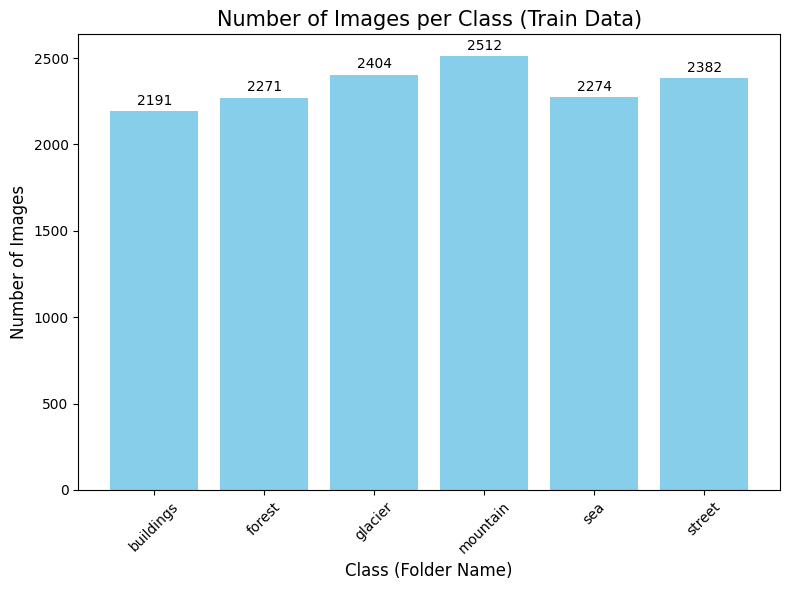

In [5]:
import os
import matplotlib.pyplot as plt

# 폴더 이름과 각 폴더의 이미지 개수를 저장할 리스트
folder_names = []
image_counts = []

for folder_name in os.listdir(trainPath):
    folder_path = os.path.join(trainPath, folder_name)
    
    # 폴더인 경우에만 처리
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        folder_names.append(folder_name)
        image_counts.append(num_images)

# 막대 그래프 그리기
plt.figure(figsize=(8, 6)) # 그래프 크기 설정
plt.bar(folder_names, image_counts, color='skyblue')

# 그래프 제목 및 축 라벨 설정
plt.title('Number of Images per Class (Train Data)', fontsize=15)
plt.xlabel('Class (Folder Name)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# x축 레이블 회전 (클래스 이름이 길 경우 겹치지 않게)
plt.xticks(rotation=45)

# 각 막대 위에 개수 텍스트 표시 (선택 사항)
for i, count in enumerate(image_counts):
    plt.text(i, count + 20, str(count), ha='center', va='bottom')

plt.tight_layout() # 레이아웃 조정
plt.show()


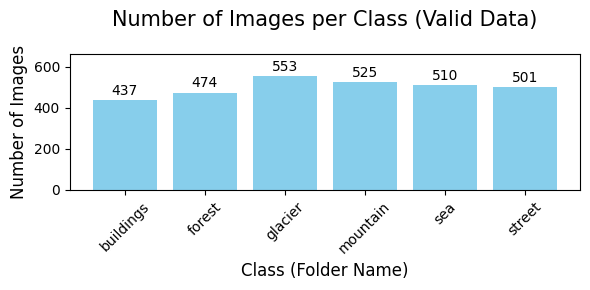

In [6]:
import os
import matplotlib.pyplot as plt

# 폴더 이름과 각 폴더의 이미지 개수를 저장할 리스트
folder_names = []
image_counts = []

validPath = os.path.join(dataPath,'seg_test','seg_test')

for folder_name in os.listdir(validPath):
    folder_path = os.path.join(validPath, folder_name)
    
    # 폴더인 경우에만 처리
    if os.path.isdir(folder_path):
        num_images = len(os.listdir(folder_path))
        folder_names.append(folder_name)
        image_counts.append(num_images)

# 막대 그래프 그리기
plt.figure(figsize=(6, 3)) # 그래프 크기 설정
plt.bar(folder_names, image_counts, color='skyblue')

# ✅ 수정된 부분 1: y축 공간을 넓혀주기 (가장 큰 막대 길이의 1.2배로 설정)
max_count = max(image_counts) if len(image_counts) > 0 else 0
plt.ylim(0, max_count * 1.2)

# ✅ 수정된 부분 2: title에 pad 설정으로 위아래 간격 벌리기
plt.title('Number of Images per Class (Valid Data)', fontsize=15, pad=20)
plt.xlabel('Class (Folder Name)', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)

# x축 레이블 회전 (클래스 이름이 길 경우 겹치지 않게)
plt.xticks(rotation=45)

# 각 막대 위에 개수 텍스트 표시
for i, count in enumerate(image_counts):
    # 텍스트 위치도 값에 비례하여 약간 위로 떨어지게 설정
    plt.text(i, count + (max_count * 0.02), str(count), ha='center', va='bottom')

plt.tight_layout() # 레이아웃 조정
plt.show()

In [7]:
# HOME/Intel_Image/seg_pred/seg_pred
import os

# 예측(pred) 데이터의 경로 설정 (dataPath가 'Intel_Image'로 설정되어 있다고 가정)
predPath = os.path.join(dataPath, 'seg_pred', 'seg_pred')

# 해당 경로가 존재하는지 확인 후 파일 갯수 계산
if os.path.exists(predPath):
    # 폴더 내의 모든 파일 목록을 가져옴
    file_list = os.listdir(predPath)
    
    # 디렉토리를 제외하고 순수 파일(이미지)만의 갯수를 구함
    # (선택 사항지만 안전하게 파일만 세는 것이 좋습니다)
    num_files = len([file for file in file_list if os.path.isfile(os.path.join(predPath, file))])
    
    print(f"seg_pred 폴더에 있는 총 파일(이미지) 갯수: {num_files}개")
else:
    print(f"에러: 해당 경로를 찾을 수 없습니다. 경로가 올바른지 확인해주세요. ({predPath})")

seg_pred 폴더에 있는 총 파일(이미지) 갯수: 7301개


In [8]:
# trainPath에서 이미지 한장을 랜덤으로 선택해서 이미지의 픽셀값을 numpy 배열로 출력하는 코드

import os
import random
import numpy as np
from PIL import Image

# 1. trainPath 내의 모든 폴더(클래스) 목록 가져오기
class_folders = [f for f in os.listdir(trainPath) if os.path.isdir(os.path.join(trainPath, f))]

if not class_folders:
    print("에러: trainPath에 클래스 폴더가 없습니다.")
else:
    # 2. 랜덤하게 폴더 하나 선택
    random_folder = random.choice(class_folders)
    folder_path = os.path.join(trainPath, random_folder)
    
    # 3. 해당 폴더 내의 모든 이미지 파일 목록 가져오기 (확장자 필터링)
    image_files = [f for f in os.listdir(folder_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
    
    if not image_files:
        print(f"에러: {random_folder} 폴더에 이미지가 없습니다.")
    else:
        # 4. 랜덤하게 이미지 파일 하나 선택
        random_image = random.choice(image_files)
        image_path = os.path.join(folder_path, random_image)
        
        print(f"선택된 클래스: {random_folder}")
        print(f"선택된 이미지 파일: {random_image}")
        print("-" * 30)
        
        # 5. 이미지를 열고 NumPy 배열로 변환
        img = Image.open(image_path)
        img_array = np.array(img)
        
        # 6. 배열의 형태(shape)와 데이터 출력
        # 보통 컬러 이미지는 (높이, 너비, 채널 수(3)) 형태를 가집니다.
        print(f"이미지 형태 (Shape): {img_array.shape}")
        print("\n--- 픽셀 값 (NumPy 배열) ---")
        print(img_array)

선택된 클래스: sea
선택된 이미지 파일: 14563.jpg
------------------------------
이미지 형태 (Shape): (150, 150, 3)

--- 픽셀 값 (NumPy 배열) ---
[[[242 208 147]
  [242 208 147]
  [243 209 148]
  ...
  [245 213 154]
  [244 212 153]
  [243 211 152]]

 [[241 207 146]
  [241 207 146]
  [242 208 147]
  ...
  [244 212 153]
  [244 212 153]
  [243 211 152]]

 [[241 207 146]
  [240 206 145]
  [240 206 145]
  ...
  [244 212 153]
  [243 211 152]
  [243 211 152]]

 ...

 [[ 13  12   8]
  [ 15  14  10]
  [ 12  11   7]
  ...
  [  7   6   2]
  [ 11  10   6]
  [  9   8   4]]

 [[  9   8   4]
  [  9   8   4]
  [  8   7   3]
  ...
  [  7   6   2]
  [ 11  10   6]
  [  9   8   4]]

 [[  7   6   2]
  [  5   4   0]
  [  8   7   3]
  ...
  [  7   6   2]
  [ 10   9   5]
  [  8   7   3]]]


## 전처리

In [9]:
# raw data의 모든 이미지가 150x150으로 되어있는지 확인, trainPath의 모든 이미지 사이즈를 확인

from PIL import Image
import os

# 확인하고 싶은 이미지 파일의 확장자들
valid_extensions = ('.jpg', '.jpeg', '.png', '.bmp')

print("이미지 크기 확인 중...")
non_150_images = []
count = 0

# trainPath 내의 모든 폴더와 파일을 순회
for root, dirs, files in os.walk(trainPath):
    for file in files:
        if file.lower().endswith(valid_extensions):
            count += 1
            file_path = os.path.join(root, file)
            
            try:
                with Image.open(file_path) as img:
                    width, height = img.size
                    if width != 150 or height != 150:
                        non_150_images.append((file_path, (width, height)))
            except Exception as e:
                print(f"파일을 열 수 없음: {file_path} (에러: {e})")

# 결과 출력
print("-" * 30)
print(f"전체 확인한 이미지 수: {count}")

if not non_150_images:
    print("모든 이미지가 150x150 크기입니다! :)")
else:
    print(f"150x150이 아닌 이미지 수: {len(non_150_images)}")
    print("\n[일부 리스트(최대 10개)]")
    for path, size in non_150_images[:10]:
        print(f"크기 {size}: {path}")


이미지 크기 확인 중...
------------------------------
전체 확인한 이미지 수: 14034
150x150이 아닌 이미지 수: 48

[일부 리스트(최대 10개)]
크기 (150, 124): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\buildings\5358.jpg
크기 (150, 113): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\1004.jpg
크기 (150, 108): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\12108.jpg
크기 (150, 133): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\14315.jpg
크기 (150, 115): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\14609.jpg
크기 (150, 135): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\15776.jpg
크기 (150, 136): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\5483.jpg
크기 (150, 108): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\5643.jpg
크기 (150, 113): c:\Users\user\github\DL_15th\Intel_Image\seg_train\seg_train\forest\7174.jpg
크기 (150, 110): c:\Users\user\github\DL_15th\Intel_Image\seg

In [ ]:
# # 이미지의 픽셀값을 0~255 -> 0~1로 변경 (정규화: Normalization)

# from tensorflow.keras.preprocessing.image import ImageDataGenerator
# import os

# # 1. 데이터 경로 설정 (이미 정의된 dataPath 변수 활용)
# train_dir = os.path.join(dataPath, 'seg_train', 'seg_train')
# test_dir = os.path.join(dataPath, 'seg_test', 'seg_test')

# # 2. ImageDataGenerator 생성
# # 훈련용: 데이터 증식(Augmentation) + 정규화(Rescale)
# train_datagen = ImageDataGenerator(
#     rescale=1./255,            # 정규화 (0~255 -> 0~1)
#     rotation_range=20,         # 무작위 회전
#     width_shift_range=0.2,     # 가로 이동
#     height_shift_range=0.2,    # 세로 이동
#     shear_range=0.2,           # 전단 변환
#     zoom_range=0.2,            # 무작위 확대/축소
#     horizontal_flip=True,      # 수평 뒤집기
#     fill_mode='nearest',       # 빈 공간 채우기 방식
#     validation_split=0.2       # 훈련 데이터의 20%를 검증용(Validation)으로 분리
# )

# # 검증 및 테스트용: 데이터 증식 없이 정규화(Rescale)만 적용
# test_datagen = ImageDataGenerator(rescale=1./255)

# # 3. Generator 설정 (폴더로부터 데이터 읽기)
# image_size = (150, 150)        # 이미지 크기 설정
# batch_size = 32

# print("--- Training Set ---")
# train_generator = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='categorical',
#     subset='training',         # 80%를 훈련용으로 설정
#     shuffle=True
# )

# print("\n--- Validation Set ---")
# val_generator = train_datagen.flow_from_directory(
#     train_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='categorical',
#     subset='validation',       # 20%를 검증용으로 설정
#     shuffle=True
# )

# print("\n--- Test Set ---")
# test_generator = test_datagen.flow_from_directory(
#     test_dir,
#     target_size=image_size,
#     batch_size=batch_size,
#     class_mode='categorical',
#     shuffle=False              # 테스트 데이터는 순서 섞지 않음
# )

# # 라벨 매핑 정보(Target값) 확인
# print(f"\nClass Indices (Target): {train_generator.class_indices}")


In [10]:
# 이미지의 픽셀값을 0~255, 0~1로 변경(정규화:Normalization)
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import tensorflow
# 1. 훈련용 데이터셋 (Train) - 데이터 증식 및 정규화(1/255) 적용
train_datagen = ImageDataGenerator(
    rescale=1./255,              # 픽셀 값을 0~1 사이로 정규화
    rotation_range=20,           # 이미지를 무작위로 회전할 각도 범위 (20도)
    width_shift_range=0.1,       # 전체 가로 크기에서 무작위 가로 이동 비율
    height_shift_range=0.1,      # 전체 세로 크기에서 무작위 세로 이동 비율
    shear_range=0.1,             # 무작위 전단 변환 비율
    zoom_range=0.1,              # 무작위 확대/축소 비율
    horizontal_flip=True,        # 무작위로 수평 뒤집기
    fill_mode='nearest'          # 이미지를 변형하면서 생기는 빈 공간을 채우는 방식
)

# 2. 검증용 데이터셋 (Valid) - 평가용이므로 정규화만 적용 (증식 X)
valid_datagen = ImageDataGenerator(rescale=1./255)

# 3. 테스트/예측용 데이터셋 (Test/Pred) - 평가용이므로 정규화만 적용 (증식 X)
test_datagen = ImageDataGenerator(rescale=1./255)

In [11]:
# --- (참고) 실제 제너레이터 생성 방법 ---
# (이미지 크기와 배치 사이즈는 필요에 따라 수정하세요)
IMG_SIZE = (150, 150)
BATCH_SIZE = 32

print("=== 훈련 데이터 준비 ===")
train_generator = train_datagen.flow_from_directory(
    trainPath,                  # 훈련 데이터 폴더 경로
    target_size=IMG_SIZE,       # 이미지 크기 조절
    batch_size=BATCH_SIZE,      # 배치 사이즈
    class_mode='categorical'    # 다중 분류이므로 'categorical' (원-핫 인코딩 반환)
)

print("\n=== 검증 데이터 준비 ===")
valid_generator = valid_datagen.flow_from_directory(
    validPath,                  # 검증 데이터 폴더 경로
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# print("\n=== 예측/테스트 데이터 준비 ===")
# # 주의: pred 데이터는 클래스 폴더 없이 하위에 바로 이미지들이 있을 수 있으므로 주의해야 합니다.
# # 일반적인 분류 문제 테스트용이라면 아래와 같이 사용합니다.
# test_generator = test_datagen.flow_from_directory(
#     predPath,                   # 예측 데이터 폴더 경로
#     target_size=IMG_SIZE,
#     batch_size=BATCH_SIZE,
#     class_mode=None,            # 예측용 데이터에는 라벨(정답)이 없는 경우가 많으므로 None
#     shuffle=False               # 예측 결과 순서를 유지하기 위해 섞지 않음
# )

=== 훈련 데이터 준비 ===
Found 14034 images belonging to 6 classes.

=== 검증 데이터 준비 ===
Found 3000 images belonging to 6 classes.


### 사전 학습 모델 사용 (Xception)

In [12]:
# 사전학습 모델 (Xception)을 가져와서 6개의 클래스를 분류하는 분류기를 추가

from tensorflow.keras.applications import Xception
from tensorflow.keras import layers, models

# 1. 사전 학습된 Xception 모델 가져오기
# weights='imagenet': ImageNet으로 학습된 가중치 사용
# include_top=False: 기존의 분류기(마지막 레이어들)는 제외. 분류기 포함한 것보다 다운할 때 용량좀 적어 ㅎㅎ
# input_shape=(150, 150, 3): 이전 단계에서 설정한 이미지 크기
base_model = Xception(weights='imagenet', include_top=False, input_shape=(150, 150, 3))

# 2. Base Model 고정 (Freezing)
# 이미 학습된 가중치를 보존하기 위해 하위 레이어들을 학습되지 않도록 설정
base_model.trainable = False

# 3. 새로운 분류기(Classifier) 추가
model = models.Sequential([
    base_model,
    layers.GlobalAveragePooling2D(),           # 4차원 텐서를 2차원으로 축약
    layers.Dense(256, activation='relu'),      # 추가적인 학습을 위한 밀집층 (옵션)
    layers.Dropout(0.5),                       # 과적합 방지
    layers.Dense(6, activation='softmax')      # 최종 6개 클래스 분류
])

# 모델 구조 요약 출력
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ xception (Functional)           │ (None, 5, 5, 2048)     │    20,861,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 2048)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       524,544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,387,566 (81.59 MB)

 Trainable params: 526,086 (2.01 MB)

 Non-trainable params: 20,861,480 (79.58 MB)

In [ ]:
# 4. 모델 컴파일
from tensorflow.keras.optimizers import Adam

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

# 2. 콜백 설정 (과적합 방지 및 최적 가중치 자동 저장)
# val_loss가 5번 연속 개선되지 않으면 학습을 미리 멈추고(조기 종료), 가장 좋은 가중치로 복원
early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# 검증 성능이 가장 좋았던 시점의 모델을 저장
checkpoint = ModelCheckpoint('intel_image_best_model.keras', monitor='val_accuracy', save_best_only=True)

In [ ]:
# 3. 모델 학습 진행 (Training)
epochs = 30

print(f"--- 모델 학습을 시작합니다 ({epochs} Epochs) ---")
history = model.fit(
    train_generator,                     # 훈련용 데이터 (전처리/증식 포함)
    validation_data=valid_generator,     # 검증용 데이터 (평가용)
    epochs=epochs,                       # 전체 데이터 반복 학습 횟수 (30)
    callbacks=[early_stop, checkpoint]   # 콜백 함수 지정
)

In [ ]:
# history를 사용하여 loss, accuracy, val_accuracy, val_loss를 그래프로 출력
import matplotlib.pyplot as plt

# history 객체에 저장된 학습 결과(loss, accuracy 등) 데이터 가져오기
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

# 에포크 수 리스트 (x축으로 사용)
epochs_range = range(1, len(acc) + 1)

plt.figure(figsize=(12, 5))

# 1. 학습 및 검증 정확도(Accuracy) 그래프
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy', marker='o')
plt.plot(epochs_range, val_acc, label='Validation Accuracy', marker='o')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True) # 눈금선 추가

# 2. 학습 및 검증 손실(Loss) 그래프
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss', marker='o')
plt.plot(epochs_range, val_loss, label='Validation Loss', marker='o')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout() # 그래프 간 간격 자동 조정
plt.show()

In [ ]:
# 강사님 그냥 간단하게 저장
model.save('intel_image_classification.keras')
print("모델이 'intel_image_classification.keras' 파일로 성공적으로 저장되었습니다.")

In [ ]:
# 아래는 ai생성 저장
from tensorflow.keras.callbacks import ModelCheckpoint
import pickle

# 1. 모델 저장 경로 설정
model_save_path = 'best_intel_model.keras'

# 4. 학습 완료 후 history 객체를 파일(pkl)로 저장
with open('train_history.pkl', 'wb') as f:
    pickle.dump(history.history, f)

print("모델 및 학습 기록 저장 완료!")
